#  Multi-Agent SR + Segmentation System (patches)
### Autoencoder Confidence Router → ESPCN / SRResNet / Blend → DeepLabV3
### - Abdulaziz Mustafa Alsulaimi 2340578
### - Abdulmjeed Khalifah 2340556
### - Abdulaziz Arab 2340584

**Pipeline:**
```
LR Image
      ↓
Autoencoder → Reconstruction Error → Confidence Score
      ↓
Score < LOW   →  ESPCN only        (simple: flat roads, grass)
Score > HIGH  →  SRResNet only     (complex: buildings, cars)
In between    →  Weighted Blend
      ↓
HR Image → DeepLabV3 Segmentation (dedicated)
      ↓
Final Segmentation Map
```


In [33]:
import subprocess, sys
pkgs = ["torch", "torchvision", "opencv-python", "scikit-image",
        "matplotlib", "tqdm", "scipy"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "--quiet"])
print(" Dependencies ready")


 Dependencies ready


In [34]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn import init
import torchvision.transforms as T
import torchvision.models.segmentation as seg_models
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1024**3,1), "GB")


Device: cuda
GPU: NVIDIA GeForce RTX 5080
VRAM: 15.9 GB


In [ ]:
ROOT          = r"C:\Users\Azozi\Desktop\patches"   # Path to dataset root
IMG_DIR       = os.path.join(ROOT, "images")
LBL_DIR       = os.path.join(ROOT, "labels")

ESPCN_PATH    = r"C:\Users\Azozi\Desktop\best_espcn_potsdam.pth"
SRRESNET_PATH = r"C:\Users\Azozi\Desktop\best_model_potsdam.pth.zip"
AUTOENC_PATH  = r"C:\Users\Azozi\Desktop\autoencoder_best.pth"
SEG_MODEL_PATH = "best_deeplabv3_seg.pth"

#  Model params 
NUM_CLASSES = 6
SCALE       = 4
PATCH_SIZE  = 256

#  Router thresholds 
# Below LOW  → ESPCN only   (simple)
# Above HIGH → SRResNet only (complex)
# Between    → smooth cosine blend
LOW_THRESH  = 0.0135
HIGH_THRESH = 0.0160

# Segmentation training 
SEG_EPOCHS = 30
SEG_BATCH  = 4
SEG_LR     = 1e-4

VALID_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')

CLASS_COLORS = [
    [255, 255, 255],  # 0 Impervious (White)
    [  0,   0, 255],  # 1 Building   (Blue)
    [  0, 255, 255],  # 2 Low Veg    (Cyan)
    [  0, 255,   0],  # 3 Tree       (Green)
    [255, 255,   0],  # 4 Car        (Yellow)
    [255,   0,   0],  # 5 Clutter    (Red)
]
CLASS_NAMES = ["Impervious surfaces","Building","Low vegetation",
               "Tree","Car","Clutter/Background"]

CLASS_WEIGHTS = torch.tensor([0.5, 1.5, 1.5, 2.0, 10.0, 4.0], dtype=torch.float32)
print(" Configuration set")


 Configuration set


In [ ]:
import torchvision.models.segmentation as seg_models   # needed later

def _sorted_pairs(img_dir, lbl_dir):

    def _key(f):
        base = os.path.splitext(f)[0]
        parts = base.split("_")
        try:
            return int(parts[-1])
        except ValueError:
            return base

    imgs   = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(VALID_EXTS)], key=_key)
    labels = []
    for img_name in imgs:
        stem = os.path.splitext(img_name)[0]
        # Try Label_N with same extension then any extension
        found = None
        for ext in VALID_EXTS:
            # Replace leading word (Image -? Label) and try
            for prefix in ["Label", "label", "LABEL", "mask", "Mask"]:
                suffix = "_".join(stem.split("_")[1:])
                candidate = os.path.join(lbl_dir, f"{prefix}_{suffix}{ext}")
                if os.path.exists(candidate):
                    found = candidate
                    break
            if found: break
        if found is None:
            # Exact same filename fallback
            exact = os.path.join(lbl_dir, img_name)
            if os.path.exists(exact):
                found = exact
        if found is None:
            print(f"  No label found for {img_name}, skipping")
            continue
        labels.append(found)
        imgs[imgs.index(img_name)] = os.path.join(img_dir, img_name)

    # Rebuild as full paths
    img_paths = [os.path.join(img_dir, f)
                 if not os.path.isabs(f) else f
                 for f in imgs if os.path.exists(os.path.join(img_dir, f) if not os.path.isabs(f) else f)]
    pairs = list(zip(img_paths, labels))
    return pairs


ALL_PAIRS = _sorted_pairs(IMG_DIR, LBL_DIR)
print(f"Total paired patches: {len(ALL_PAIRS)}")
if len(ALL_PAIRS) == 0:
    raise ValueError(
        f" No pairs found!\n"
        f"  IMG_DIR = {IMG_DIR}\n"
        f"  LBL_DIR = {LBL_DIR}\n"
        f"  Check that both folders exist and files share a numeric suffix."
    )

# Deterministic 70/20/10 split
np.random.seed(42)
idx   = np.random.permutation(len(ALL_PAIRS))
n     = len(ALL_PAIRS)
t_end = int(n * 0.70)
v_end = int(n * 0.90)

TRAIN_PAIRS = [ALL_PAIRS[i] for i in idx[:t_end]]
VAL_PAIRS   = [ALL_PAIRS[i] for i in idx[t_end:v_end]]
TEST_PAIRS  = [ALL_PAIRS[i] for i in idx[v_end:]]
print(f"Train: {len(TRAIN_PAIRS)} | Val: {len(VAL_PAIRS)} | Test: {len(TEST_PAIRS)}")


def parse_mask(mask_path):

    raw = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if raw is None:
        raise FileNotFoundError(f"Cannot read mask: {mask_path}")
    if len(raw.shape) == 3:
        rgb  = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        mask = np.full(rgb.shape[:2], 5, dtype=np.int64)
        for ci, color in enumerate(CLASS_COLORS):
            mask[np.all(rgb == color, axis=-1)] = ci
    else:
        mask = raw.astype(np.int64)
        mask[(mask < 0) | (mask >= NUM_CLASSES)] = 5
    return mask


class PotsdamDataset(Dataset):

    def __init__(self, pairs, scale_factor=4, augment=False):
        self.pairs   = pairs
        self.scale   = scale_factor
        self.augment = augment
        self.to_t    = T.ToTensor()

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        hr = cv2.imread(img_path)
        if hr is None:
            raise FileNotFoundError(f"Cannot read image: {img_path}")
        hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)

        h, w = hr.shape[:2]
        lr   = cv2.resize(hr, (w // self.scale, h // self.scale),
                          interpolation=cv2.INTER_CUBIC)
        mask = parse_mask(mask_path)

        if self.augment:
            if np.random.rand() > 0.5:
                hr, lr, mask = np.fliplr(hr).copy(), np.fliplr(lr).copy(), np.fliplr(mask).copy()
            if np.random.rand() > 0.5:
                hr, lr, mask = np.flipud(hr).copy(), np.flipud(lr).copy(), np.flipud(mask).copy()
            k = np.random.randint(4)
            if k > 0:
                hr   = np.rot90(hr,   k).copy()
                lr   = np.rot90(lr,   k).copy()
                mask = np.rot90(mask, k).copy()

        return self.to_t(lr), self.to_t(hr), torch.from_numpy(mask)


def get_train_dataset(): return PotsdamDataset(TRAIN_PAIRS, SCALE, augment=True)
def get_val_dataset():   return PotsdamDataset(VAL_PAIRS,   SCALE, augment=False)
def get_test_dataset():  return PotsdamDataset(TEST_PAIRS,  SCALE, augment=False)
print(" Dataset ready")


Total paired patches: 2400
Train: 1680 | Val: 480 | Test: 240
 Dataset ready


In [ ]:
# 1. AUTOENCODER (router + SR) 
class SRAutoencoder(nn.Module):
    def __init__(self, scale_factor=4, in_channels=3):
        super().__init__()
        self.scale = scale_factor
        self.enc1 = nn.Sequential(nn.Conv2d(in_channels, 64, 3, padding=1), nn.PReLU(64))
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.PReLU(128))
        self.enc3 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.PReLU(256))
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(256,128,4,stride=2,padding=1), nn.PReLU(128))
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(128, 64,4,stride=2,padding=1), nn.PReLU(64))
        self.dec3 = nn.Conv2d(64, in_channels, 3, padding=1)
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.orthogonal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(e1); e3=self.enc3(e2)
        d1=self.dec1(e3); d2=self.dec2(d1)
        return torch.clamp(self.dec3(d2), 0.0, 1.0)


# 2. ESPCN 
class ASPP(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.b1   = nn.Sequential(nn.Conv2d(ch,ch,3,padding=1, dilation=1),nn.ReLU(True))
        self.b2   = nn.Sequential(nn.Conv2d(ch,ch,3,padding=2, dilation=2),nn.ReLU(True))
        self.b4   = nn.Sequential(nn.Conv2d(ch,ch,3,padding=4, dilation=4),nn.ReLU(True))
        self.fuse = nn.Conv2d(ch*3, ch, 1)
    def forward(self, x):
        return self.fuse(torch.cat([self.b1(x), self.b2(x), self.b4(x)], dim=1))

class ESPCNSeg(nn.Module):
    def __init__(self, scale_factor=4, num_classes=6, feat=64):
        super().__init__()
        self.scale = scale_factor
        self.feat_extract = nn.Sequential(
            nn.Conv2d(3, feat, 5, padding=2), nn.PReLU(),
            nn.Conv2d(feat, feat, 3, padding=1), nn.PReLU(),
            nn.Conv2d(feat, feat, 3, padding=1), nn.PReLU(),
        )
        self.aspp = ASPP(feat)
        self.subpixel = nn.Sequential(
            nn.Conv2d(feat, feat*(scale_factor**2), 3, padding=1),
            nn.PixelShuffle(scale_factor), nn.PReLU(),
        )
        self.seg_head = nn.Sequential(
            nn.Conv2d(feat,32,1),nn.ReLU(True),
            nn.Conv2d(32,32,3,padding=1),nn.ReLU(True),
            nn.Conv2d(32,num_classes,1),
        )
        self.recon = nn.Conv2d(feat, 3, 3, padding=1)
        sp = self.subpixel[0]; s = scale_factor
        sub = init.kaiming_normal_(
            torch.empty([sp.weight.shape[0]//(s**2)]+list(sp.weight.shape[1:])),
            nonlinearity="leaky_relu")
        sp.weight.data.copy_(sub.repeat(s**2,1,1,1))
    def forward(self, x):
        x = x-0.5; feat=self.aspp(self.feat_extract(x)); hr_feat=self.subpixel(feat)
        seg_map=self.seg_head(hr_feat); att=torch.softmax(seg_map,dim=1).max(dim=1,keepdim=True)[0]
        return self.recon(hr_feat*(1.+att))+0.5, seg_map


# 3. SRResNet 
class PartialConv(nn.Module):
    def __init__(self, ic, oc, ks, stride=1, padding=0, bias=True):
        super().__init__()
        conv = nn.Conv2d(ic, oc, ks, stride, padding, bias=bias)
        self.conv = nn.utils.weight_norm(conv)
        self.weight_mask = torch.ones(1,1,ks,ks)
        self.slide = ks*ks
    def forward(self, x):
        with torch.no_grad():
            mask = torch.ones(x.size(0),1,x.size(2),x.size(3)).to(x.device)
            mc   = F.conv2d(mask, self.weight_mask.to(x.device),
                            stride=self.conv.stride, padding=self.conv.padding)
        out = self.conv(x); ratio = self.slide/(mc+1e-8)
        if self.conv.bias is not None:
            b = self.conv.bias.view(1,-1,1,1)
            return (out-b)*ratio+b
        return out*ratio

class ResidualBlock(nn.Module):
    def __init__(self, ch=64):
        super().__init__()
        self.c1=PartialConv(ch,ch,3,padding=1); self.p=nn.PReLU(); self.c2=PartialConv(ch,ch,3,padding=1)
    def forward(self,x): return x + self.c2(self.p(self.c1(x)))*0.1

class UpsampleBlock(nn.Module):
    def __init__(self, ch=64, sf=2):
        super().__init__()
        conv=nn.Conv2d(ch,ch*(sf**2),3,padding=1)
        sub=init.kaiming_normal_(torch.randn([conv.weight.shape[0]//(sf**2)]+list(conv.weight.shape[1:])),
                                  nonlinearity="leaky_relu")
        conv.weight.data.copy_(sub.repeat(sf**2,1,1,1))
        self.block=nn.Sequential(conv,nn.PixelShuffle(sf),nn.PReLU())
    def forward(self,x): return self.block(x)

class SRResNetSeg(nn.Module):
    def __init__(self, num_residual_blocks=16, scale_factor=4, num_classes=6):
        super().__init__()
        self.conv1=nn.Sequential(nn.Conv2d(3,64,9,padding=4),nn.PReLU())
        self.res=nn.Sequential(*[ResidualBlock(64) for _ in range(num_residual_blocks)])
        self.conv2=PartialConv(64,64,3,padding=1)
        self.aspp=ASPP(64)
        self.up=(nn.Sequential(UpsampleBlock(64,2),UpsampleBlock(64,2))
                 if scale_factor==4 else UpsampleBlock(64,scale_factor))
        self.seg_head=nn.Sequential(
            nn.Conv2d(64,16,1),nn.ReLU(True),
            nn.Conv2d(16,16,3,padding=1),nn.ReLU(True),
            nn.Conv2d(16,num_classes,1),
        )
        self.conv3=nn.Conv2d(64,3,9,padding=4)
    def forward(self,x):
        x=x-0.5; init_=self.conv1(x)
        out=self.conv2(self.res(init_))+init_
        out=self.aspp(out); out=self.up(out)
        seg=self.seg_head(out)
        att=torch.softmax(seg,dim=1).max(dim=1,keepdim=True)[0]
        return self.conv3(out*(1.+att))+0.5, seg


# 4. DeepLabV3 (dedicated segmentation on HR) 
class DeepLabSeg(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.model=seg_models.deeplabv3_resnet50(weights="DEFAULT")
        self.model.classifier[4]    =nn.Conv2d(256,num_classes,1)
        self.model.aux_classifier[4]=nn.Conv2d(256,num_classes,1)
    def forward(self,x): return self.model(x)["out"]

print(" All architectures defined")


 All architectures defined


In [ ]:
def load_autoencoder():
    m = SRAutoencoder(scale_factor=SCALE).to(DEVICE)

    checkpoint = torch.load(AUTOENC_PATH, map_location=DEVICE)

    #  Handle checkpoint wrappers 
    if isinstance(checkpoint, dict):
        if "model_state" in checkpoint:
            state = checkpoint["model_state"]
        elif "state_dict" in checkpoint:
            state = checkpoint["state_dict"]
        else:
            state = checkpoint
    else:
        state = checkpoint

    #  Rename old keys to new keys 
    fixed_state = {}

    for k, v in state.items():

        # Old reconstruction head -> new decoder layer
        if k.startswith("recon."):
            new_k = k.replace("recon.", "dec3.")
            fixed_state[new_k] = v

        # Ignore segmentation head if current model has no seg head
        elif k.startswith("seg_head."):
            continue

        else:
            fixed_state[k] = v

    missing, unexpected = m.load_state_dict(fixed_state, strict=False)

    print(f" Autoencoder loaded from {AUTOENC_PATH}")

    if missing:
        print(f" Missing keys: {missing}")

    if unexpected:
        print(f" Unexpected keys ignored: {unexpected}")

    m.eval()
    return m


# ESPCN Loader
def load_espcn():
    m = ESPCNSeg(
        scale_factor=SCALE,
        num_classes=NUM_CLASSES
    ).to(DEVICE)

    checkpoint = torch.load(ESPCN_PATH, map_location=DEVICE)

    if isinstance(checkpoint, dict):
        if "model_state" in checkpoint:
            state = checkpoint["model_state"]
        elif "state_dict" in checkpoint:
            state = checkpoint["state_dict"]
        else:
            state = checkpoint
    else:
        state = checkpoint

    missing, unexpected = m.load_state_dict(state, strict=False)

    print(f" ESPCN loaded from {ESPCN_PATH}")

    if missing:
        print(f" Missing keys: {missing}")

    if unexpected:
        print(f" Unexpected keys ignored: {unexpected}")

    m.eval()
    return m


# SRResNet Loader
def load_srresnet():
    m = SRResNetSeg(
        num_residual_blocks=16,
        scale_factor=SCALE,
        num_classes=NUM_CLASSES
    ).to(DEVICE)

    checkpoint = torch.load(SRRESNET_PATH, map_location=DEVICE)

    # unwrap checkpoint
    if isinstance(checkpoint, dict):
        if "model_state" in checkpoint:
            state = checkpoint["model_state"]
        elif "state_dict" in checkpoint:
            state = checkpoint["state_dict"]
        else:
            state = checkpoint
    else:
        state = checkpoint

    fixed_state = {}

    for k, v in state.items():

        # residual_blocks -> res
        if k.startswith("residual_blocks."):
            new_k = k.replace("residual_blocks.", "res.")
            new_k = new_k.replace(".conv1.", ".c1.")
            new_k = new_k.replace(".conv2.", ".c2.")
            new_k = new_k.replace(".prelu.", ".p.")
            fixed_state[new_k] = v

        # upsample_blocks -> up
        elif k.startswith("upsample_blocks."):
            new_k = k.replace("upsample_blocks.", "up.")
            fixed_state[new_k] = v

        else:
            fixed_state[k] = v

    missing, unexpected = m.load_state_dict(fixed_state, strict=False)

    print(f" SRResNet loaded from {SRRESNET_PATH}")

    if missing:
        print(f" Missing keys: {missing}")

    if unexpected:
        print(f" Unexpected keys ignored: {unexpected}")

    m.eval()
    return m


# LOAD ALL MODELS
autoencoder = load_autoencoder()
espcn       = load_espcn()
srresnet    = load_srresnet()

print("\n All models loaded successfully.")

 Autoencoder loaded from C:\Users\Azozi\Desktop\autoencoder_best.pth
 ESPCN loaded from C:\Users\Azozi\Desktop\best_espcn_potsdam.pth
 SRResNet loaded from C:\Users\Azozi\Desktop\best_model_potsdam.pth.zip

 All models loaded successfully.


In [ ]:
def compute_confidence(ae, lr_batch):

    with torch.no_grad():
        recon_hr = ae(lr_batch)
        # Downsample back to LR spatial size for a fair comparison
        recon_lr = F.interpolate(recon_hr, size=lr_batch.shape[2:],
                                 mode="bilinear", align_corners=False)
        return (lr_batch - recon_lr).abs().mean(dim=[1, 2, 3])

def smooth_weight(error, low=LOW_THRESH, high=HIGH_THRESH):
    w = torch.zeros_like(error)
    mid    = (error >= low) & (error <= high)
    high_m = error > high
    t = (error[mid] - low) / (high - low)
    w[mid]    = 0.5 * (1 - torch.cos(torch.pi * t))
    w[high_m] = 1.0
    return w

def route_and_blend(ae, espcn, srresnet, lr_batch):
    errors  = compute_confidence(ae, lr_batch)
    weights = smooth_weight(errors)

    with torch.no_grad():
        sr_e, _ = espcn(lr_batch)
        sr_r, _ = srresnet(lr_batch)

    h = min(sr_e.shape[2], sr_r.shape[2])
    w = min(sr_e.shape[3], sr_r.shape[3])
    sr_e = sr_e[:, :, :h, :w]
    sr_r = sr_r[:, :, :h, :w]

    wv       = weights.view(-1, 1, 1, 1).to(DEVICE)
    sr_blend = ((1.0 - wv) * sr_e + wv * sr_r).clamp(0, 1)

    return sr_blend, {
        "errors":       errors.cpu().numpy(),
        "weights":      weights.cpu().numpy(),
        "espcn_pct":    ((weights == 0.0).sum() / len(weights) * 100).item(),
        "srresnet_pct": ((weights == 1.0).sum() / len(weights) * 100).item(),
        "blend_pct":    (((weights > 0) & (weights < 1)).sum() / len(weights) * 100).item(),
    }

# Quick sanity check
_lr, _hr, _ = get_val_dataset()[0]
_lr = _lr.unsqueeze(0).to(DEVICE)
_sr, _info = route_and_blend(autoencoder, espcn, srresnet, _lr)
print(f" Router OK | SR shape: {tuple(_sr.shape)}")
print(f"   Error: {_info['errors'][0]:.4f}  Weight: {_info['weights'][0]:.3f}")
del _lr, _hr, _sr, _info

 Router OK | SR shape: (1, 3, 300, 300)
   Error: 0.0125  Weight: 0.000


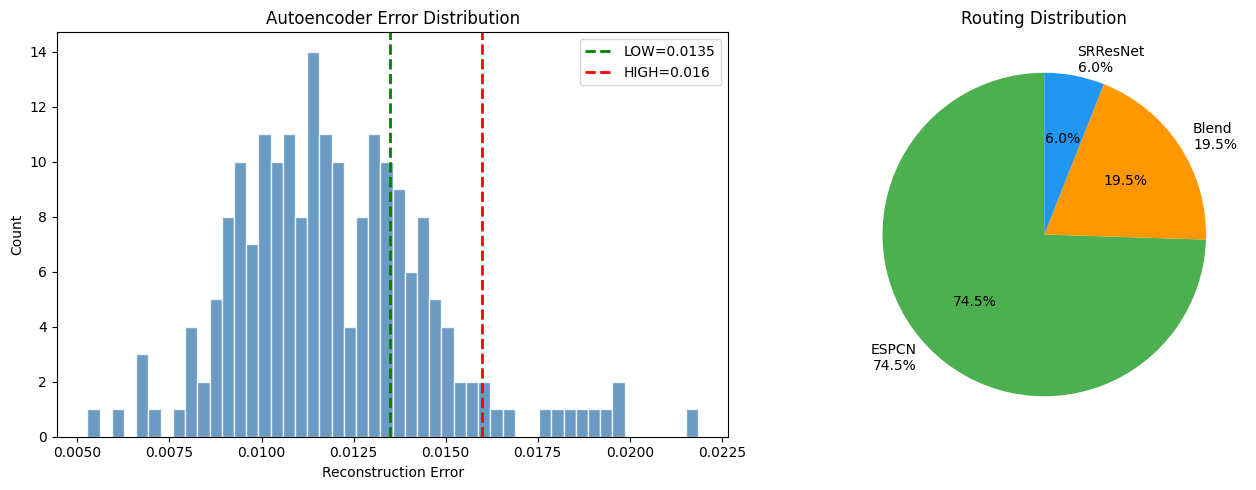

ESPCN:149  Blend:39  SRResNet:12


In [40]:
def visualize_routing(n_samples=200):
    loader = DataLoader(get_val_dataset(), batch_size=1, shuffle=True, num_workers=0)
    errors, weights_list = [], []
    for i, (lr_b, *_) in enumerate(loader):
        if i >= n_samples: break
        err = compute_confidence(autoencoder, lr_b.to(DEVICE))
        w   = smooth_weight(err)
        errors.append(err.item()); weights_list.append(w.item())

    errors  = np.array(errors)
    weights = np.array(weights_list)
    e_cnt = (weights==0.0).sum(); r_cnt=(weights==1.0).sum(); b_cnt=((weights>0)&(weights<1)).sum()
    total = len(weights)

    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    axes[0].hist(errors, bins=50, color="steelblue", alpha=0.8, edgecolor="white")
    axes[0].axvline(LOW_THRESH,  color="green", linestyle="--", linewidth=2, label=f"LOW={LOW_THRESH}")
    axes[0].axvline(HIGH_THRESH, color="red",   linestyle="--", linewidth=2, label=f"HIGH={HIGH_THRESH}")
    axes[0].set_xlabel("Reconstruction Error"); axes[0].set_ylabel("Count")
    axes[0].set_title("Autoencoder Error Distribution"); axes[0].legend()

    axes[1].pie(
        [e_cnt, b_cnt, r_cnt],
        labels=[f"ESPCN\n{e_cnt/total*100:.1f}%",
                f"Blend\n{b_cnt/total*100:.1f}%",
                f"SRResNet\n{r_cnt/total*100:.1f}%"],
        colors=["#4CAF50","#FF9800","#2196F3"], autopct="%1.1f%%", startangle=90)
    axes[1].set_title("Routing Distribution")
    plt.tight_layout(); plt.savefig("routing_analysis.png", dpi=120, bbox_inches="tight"); plt.show()
    print(f"ESPCN:{e_cnt}  Blend:{b_cnt}  SRResNet:{r_cnt}")

visualize_routing()


In [41]:
def train_segmentation():
    train_ds = get_train_dataset(); val_ds = get_val_dataset()
    train_loader = DataLoader(train_ds, batch_size=SEG_BATCH, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=2,         shuffle=False, num_workers=0)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

    seg_model = DeepLabSeg(NUM_CLASSES).to(DEVICE)
    backbone_p = [p for n,p in seg_model.named_parameters() if "backbone" in n]
    head_p     = [p for n,p in seg_model.named_parameters() if "backbone" not in n]
    optimizer  = optim.AdamW([{"params":backbone_p,"lr":SEG_LR*0.1},
                               {"params":head_p,    "lr":SEG_LR}], weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SEG_EPOCHS, eta_min=1e-6)
    scaler     = torch.amp.GradScaler("cuda")
    ce_fn      = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE), label_smoothing=0.1)

    best_miou, losses = 0.0, []
    mean_t = torch.tensor([0.485,0.456,0.406], device=DEVICE).view(1,3,1,1)
    std_t  = torch.tensor([0.229,0.224,0.225], device=DEVICE).view(1,3,1,1)

    for epoch in range(SEG_EPOCHS):
        seg_model.train(); epoch_loss = 0.0
        pbar = tqdm(train_loader, desc=f"SegEpoch {epoch+1:3d}/{SEG_EPOCHS}")
        for lr_b, hr_b, mask_b in pbar:
            lr_b, hr_b, mask_b = lr_b.to(DEVICE), hr_b.to(DEVICE), mask_b.to(DEVICE)
            with torch.no_grad():
                sr_b, _ = route_and_blend(autoencoder, espcn, srresnet, lr_b)

            hs,ws=sr_b.shape[2:]; hh,wh=hr_b.shape[2:]
            t=(hh-hs)//2; l=(wh-ws)//2
            # hr_b aligned not needed for seg — sr_b is the input

            with torch.amp.autocast("cuda"):
                sr_norm    = (sr_b - mean_t) / std_t
                seg_logits = seg_model(sr_norm)
                if seg_logits.shape[2:] != mask_b.shape[1:]:
                    seg_logits = F.interpolate(seg_logits, size=mask_b.shape[1:],
                                               mode="bilinear", align_corners=False)
                loss_ce   = ce_fn(seg_logits, mask_b)
                ps        = torch.softmax(seg_logits, dim=1)
                oh        = F.one_hot(mask_b, NUM_CLASSES).permute(0,3,1,2).float()
                inter     = (ps*oh).sum(dim=(2,3)); card = ps.sum(dim=(2,3))+oh.sum(dim=(2,3))
                loss_dice = (1-(2*inter+1e-6)/(card+1e-6)).mean()
                loss      = 0.6*loss_ce + 0.4*loss_dice

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(seg_model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            epoch_loss += loss.item(); pbar.set_postfix({"loss":f"{loss.item():.4f}"})

        avg_loss = epoch_loss/len(train_loader); losses.append(avg_loss); scheduler.step()

        if (epoch+1)%5==0 or epoch==SEG_EPOCHS-1:
            seg_model.eval()
            conf = np.zeros((NUM_CLASSES,NUM_CLASSES), dtype=np.int64)
            with torch.no_grad():
                for lr_b, hr_b, mask_b in tqdm(val_loader, desc="  Val", leave=False):
                    sr_b, _ = route_and_blend(autoencoder, espcn, srresnet, lr_b.to(DEVICE))
                    sl = seg_model((sr_b-mean_t)/std_t)
                    if sl.shape[2:] != mask_b.shape[1:]:
                        sl = F.interpolate(sl, size=mask_b.shape[1:],
                                           mode="bilinear", align_corners=False)
                    pred=sl.argmax(1).cpu().numpy().flatten()
                    gt  =mask_b.numpy().flatten()
                    conf+=np.bincount(gt*NUM_CLASSES+pred,
                                      minlength=NUM_CLASSES**2).reshape(NUM_CLASSES,NUM_CLASSES)
            tp=np.diag(conf); iou=tp/(conf.sum(0)+conf.sum(1)-tp+1e-15)
            miou=iou.mean(); acc=tp.sum()/conf.sum()
            tqdm.write(f"Epoch {epoch+1} | Loss:{avg_loss:.4f} | mIoU:{miou:.4f} | Acc:{acc:.4f}")
            if miou > best_miou:
                best_miou = miou
                torch.save(seg_model.state_dict(), SEG_MODEL_PATH)
                tqdm.write(f"  >>> SAVED BEST SEG mIoU={best_miou:.4f}")
        else:
            tqdm.write(f"Epoch {epoch+1} | Loss:{avg_loss:.4f}")

    return seg_model, losses

seg_model, seg_losses = train_segmentation()


Train: 1680 | Val: 480


SegEpoch   1/30: 100%|██████████| 420/420 [00:48<00:00,  8.71it/s, loss=1.2875]


Epoch 1 | Loss:1.3791


SegEpoch   2/30: 100%|██████████| 420/420 [00:50<00:00,  8.34it/s, loss=1.1574]


Epoch 2 | Loss:1.2375


...

Epoch 28 | Loss:1.0071


SegEpoch  29/30: 100%|██████████| 420/420 [00:48<00:00,  8.72it/s, loss=1.1044]


Epoch 29 | Loss:1.0081


SegEpoch  30/30: 100%|██████████| 420/420 [00:48<00:00,  8.70it/s, loss=0.9617]


Epoch 30 | Loss:0.9994 | mIoU:0.5707 | Acc:0.7643
  >>> SAVED BEST SEG mIoU=0.5707


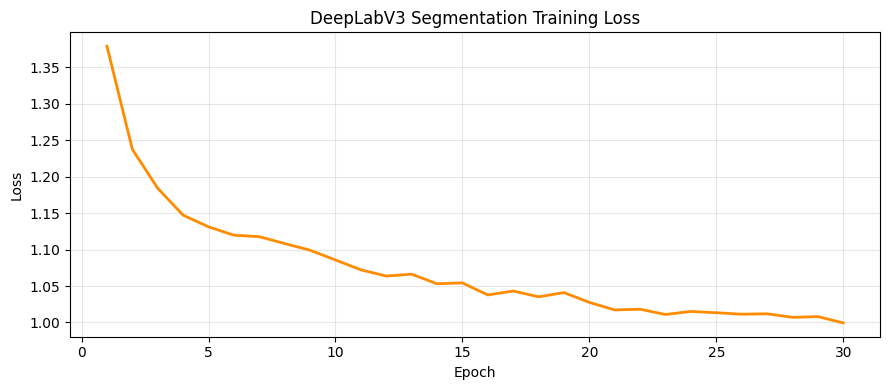

In [42]:
plt.figure(figsize=(9,4))
plt.plot(range(1,len(seg_losses)+1), seg_losses, linewidth=2, color="darkorange")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("DeepLabV3 Segmentation Training Loss")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [43]:
def classmap_to_color(cls_map):
    c=np.zeros((*cls_map.shape,3),dtype=np.uint8)
    for ci,rgb in enumerate(CLASS_COLORS): c[cls_map==ci]=rgb
    return c

def make_legend():
    return [mpatches.Patch(color=[c/255 for c in rgb],label=name)
            for name,rgb in zip(CLASS_NAMES,CLASS_COLORS)]

def evaluate_full(ae, espcn, srresnet, seg_model):
    seg_model.eval()
    val_loader = DataLoader(get_val_dataset(), batch_size=1, shuffle=False, num_workers=0)
    psnr_list, ssim_list = [], []
    conf = np.zeros((NUM_CLASSES,NUM_CLASSES),dtype=np.int64)
    mean_t=torch.tensor([0.485,0.456,0.406],device=DEVICE).view(1,3,1,1)
    std_t =torch.tensor([0.229,0.224,0.225],device=DEVICE).view(1,3,1,1)

    with torch.no_grad():
        for lr_b,hr_b,mask_b in tqdm(val_loader,desc="Evaluating"):
            sr_b,info=route_and_blend(ae,espcn,srresnet,lr_b.to(DEVICE))
            sr_np=np.clip(sr_b.squeeze().permute(1,2,0).cpu().numpy(),0,1)
            hr_np=np.clip(hr_b.squeeze().permute(1,2,0).numpy(),0,1)
            psnr_list.append(psnr_fn(hr_np,sr_np,data_range=1.0))
            ssim_list.append(ssim_fn(hr_np,sr_np,channel_axis=2,data_range=1.0))
            sl=seg_model((sr_b-mean_t)/std_t)
            if sl.shape[2:]!=mask_b.shape[1:]:
                sl=F.interpolate(sl,size=mask_b.shape[1:],mode="bilinear",align_corners=False)
            pred=sl.argmax(1).cpu().numpy().flatten(); gt=mask_b.numpy().flatten()
            conf+=np.bincount(gt*NUM_CLASSES+pred,minlength=NUM_CLASSES**2).reshape(NUM_CLASSES,NUM_CLASSES)

    tp=np.diag(conf); fp=conf.sum(0)-tp; fn=conf.sum(1)-tp; eps=1e-15
    iou=tp/(tp+fp+fn+eps); prec=tp/(tp+fp+eps); rec=tp/(tp+fn+eps)
    f1=2*prec*rec/(prec+rec+eps)
    print("\n"+"="*58); print("    MULTI-AGENT SYSTEM — FULL EVALUATION"); print("="*58)
    print(f"  PSNR     : {np.mean(psnr_list):.2f} dB")
    print(f"  SSIM     : {np.mean(ssim_list):.4f}")
    print(f"  Accuracy : {tp.sum()/conf.sum():.4f}")
    print(f"  mIoU     : {iou.mean():.4f}  ({iou.mean()*100:.1f}%)")
    print(f"  Macro F1 : {f1.mean():.4f}")
    print("\n  PER-CLASS IoU + F1"); print("="*58)
    for name,iu,f in zip(CLASS_NAMES,iou,f1):
        print(f"  {name:22s}: IoU={iu:.3f}  F1={f:.3f}  {'#'*int(iu*20)}")
    print("="*58)

if os.path.exists(SEG_MODEL_PATH):
    seg_model.load_state_dict(torch.load(SEG_MODEL_PATH, map_location=DEVICE))
    print(f" Loaded best seg weights")
evaluate_full(autoencoder, espcn, srresnet, seg_model)


 Loaded best seg weights


Evaluating: 100%|██████████| 480/480 [00:20<00:00, 22.98it/s]


    MULTI-AGENT SYSTEM — FULL EVALUATION
  PSNR     : 26.28 dB
  SSIM     : 0.7202
  Accuracy : 0.7643
  mIoU     : 0.5707  (57.1%)
  Macro F1 : 0.7204

  PER-CLASS IoU + F1
  Impervious surfaces   : IoU=0.642  F1=0.782  ############
  Building              : IoU=0.778  F1=0.875  ###############
  Low vegetation        : IoU=0.573  F1=0.728  ###########
  Tree                  : IoU=0.496  F1=0.663  #########
  Car                   : IoU=0.496  F1=0.663  #########
  Clutter/Background    : IoU=0.440  F1=0.611  ########


>>> Saved: multiagent_sample.png


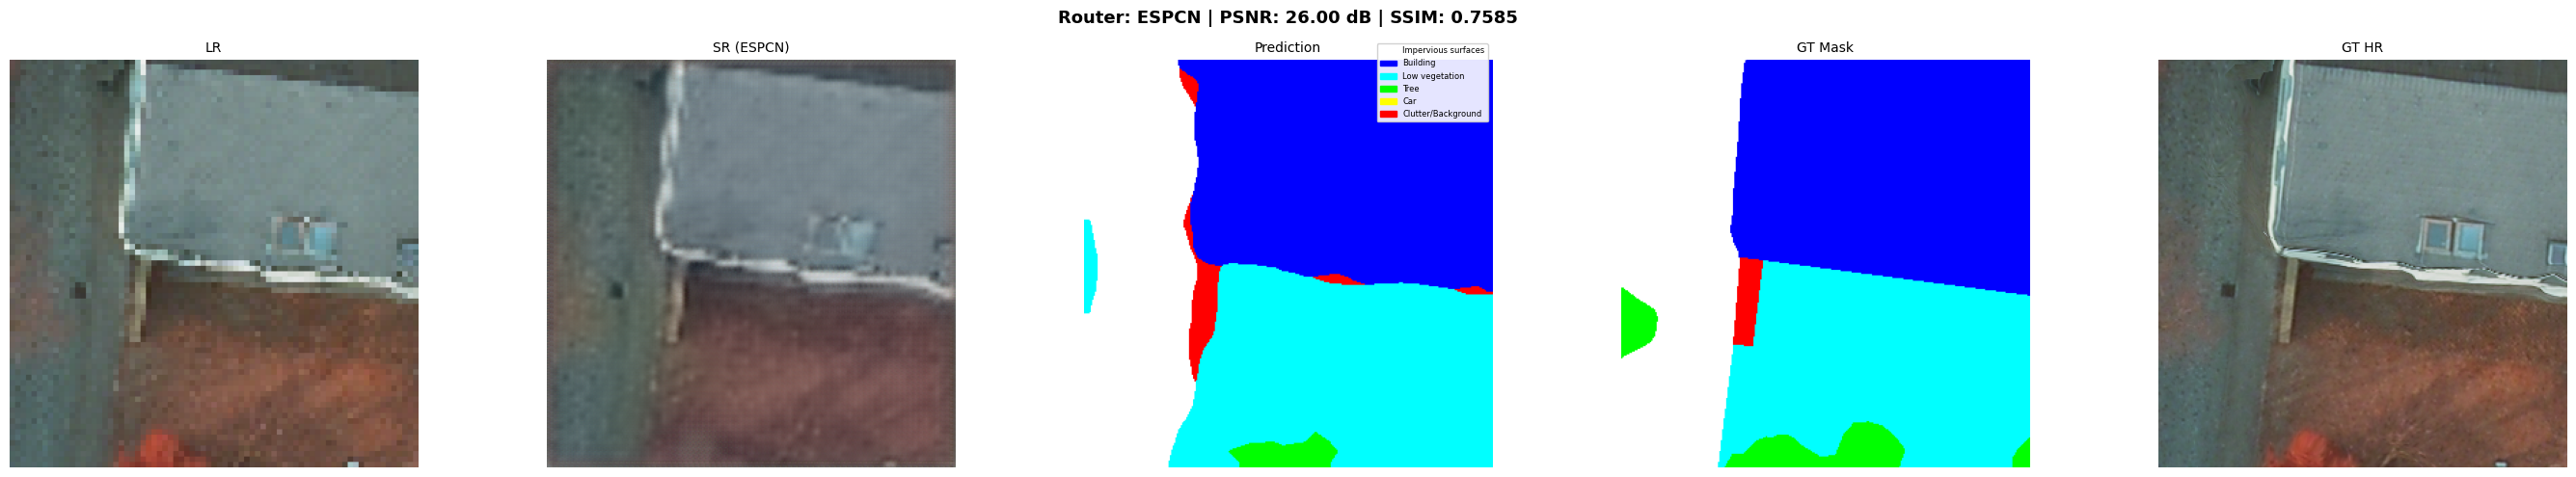

In [44]:
def visualize_sample(ae, espcn, srresnet, seg_model):
    seg_model.eval()
    ds=get_val_dataset()
    lr_t,hr_t,mask_t=ds[np.random.randint(len(ds))]
    lr_b=lr_t.unsqueeze(0).to(DEVICE)
    sr_b,info=route_and_blend(ae,espcn,srresnet,lr_b)
    mean_t=torch.tensor([0.485,0.456,0.406],device=DEVICE).view(1,3,1,1)
    std_t =torch.tensor([0.229,0.224,0.225],device=DEVICE).view(1,3,1,1)
    with torch.no_grad():
        sl=seg_model((sr_b-mean_t)/std_t)
        if sl.shape[2:]!=mask_t.shape: sl=F.interpolate(sl,size=mask_t.shape,mode="bilinear",align_corners=False)
    lr_np =cv2.resize(lr_t.permute(1,2,0).numpy(),(hr_t.shape[2],hr_t.shape[1]),interpolation=cv2.INTER_NEAREST)
    sr_np =np.clip(sr_b.squeeze().permute(1,2,0).cpu().numpy(),0,1)
    hr_np =hr_t.permute(1,2,0).numpy()
    seg_c =classmap_to_color(sl.argmax(1).squeeze().cpu().numpy())
    gt_c  =classmap_to_color(mask_t.numpy())
    w=info["weights"][0]; route="ESPCN" if w==0 else ("SRResNet" if w==1 else f"Blend({w:.2f})")
    p=psnr_fn(hr_np,sr_np,data_range=1.0); s=ssim_fn(hr_np,sr_np,channel_axis=2,data_range=1.0)
    fig,axes=plt.subplots(1,5,figsize=(28,5))
    plt.suptitle(f"Router: {route} | PSNR: {p:.2f} dB | SSIM: {s:.4f}",fontsize=13,fontweight="bold")
    for ax,(img,t) in zip(axes,[(lr_np,"LR"),(sr_np,f"SR ({route})"),(seg_c,"Prediction"),(gt_c,"GT Mask"),(hr_np,"GT HR")]):
        ax.imshow(img); ax.set_title(t,fontsize=10); ax.axis("off")
    axes[2].legend(handles=make_legend(),loc="upper right",bbox_to_anchor=(1,1.05),fontsize=6,framealpha=0.9)
    plt.tight_layout(); plt.savefig("multiagent_sample.png",dpi=150,bbox_inches="tight")
    print(">>> Saved: multiagent_sample.png"); plt.show()

visualize_sample(autoencoder, espcn, srresnet, seg_model)
